In [ ]:
!pip install -q pandera

In [ ]:
# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pandera as pa

print(pa.__version__)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

0.32.1


In [ ]:
!mkdir -p ~/.kaggle && echo KGAT_17691c0e1f5de5d3007fe6ee6706235b > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token
!pip install -q -U kaggle

!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q -o creditcardfraud.zip
!ls -lh

df = pd.read_csv('creditcard.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)
total 210M
-rw-r--r-- 1 root root 144M Sep 20  2019 creditcard.csv
-rw-r--r-- 1 root root  66M Sep 20  2019 creditcardfraud.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


In [ ]:
fraud_count = df["Class"].sum()
total_transactions = len(df)

print(f"Fraudulent Transactions: {fraud_count}")
print(f"Legitimate Transactions: {total_transactions - fraud_count}")
print(f"Total Transactions: {total_transactions}")

Fraudulent Transactions: 492
Legitimate Transactions: 284315
Total Transactions: 284807


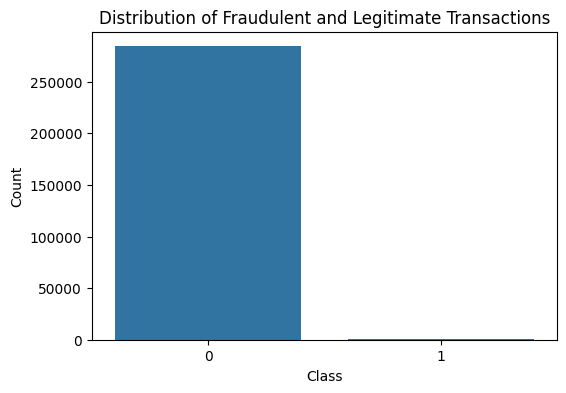

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
class_percent = df["Class"].value_counts(normalize=True) * 100

print(class_percent)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


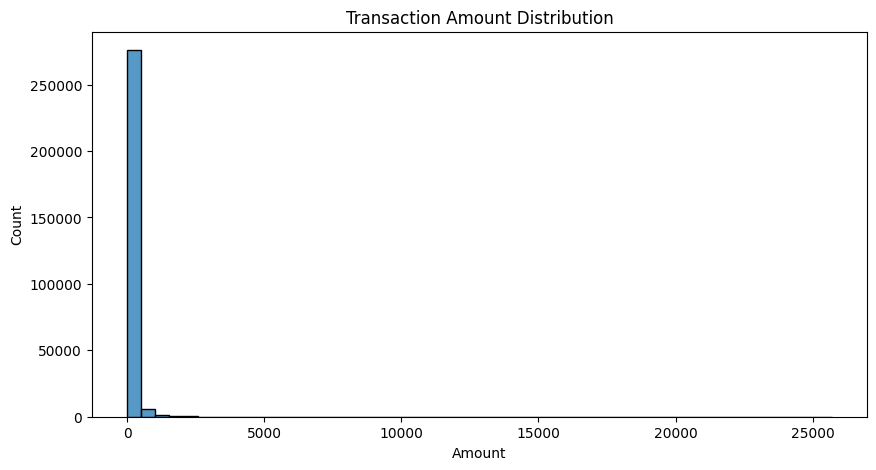

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

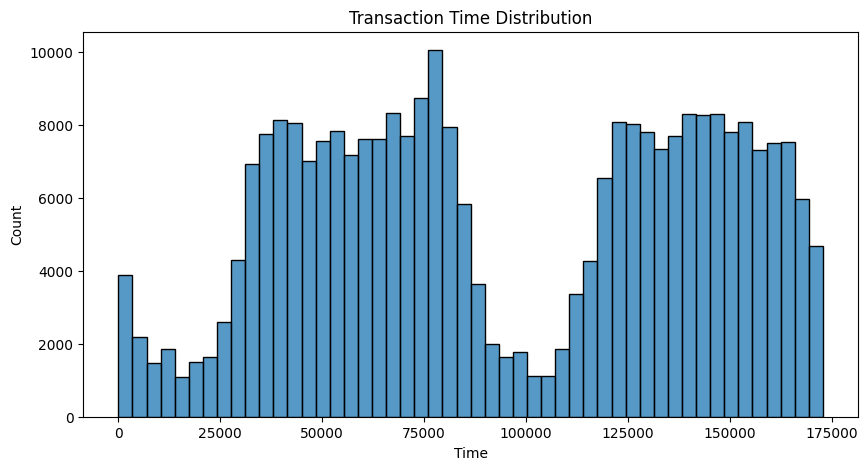

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.show()

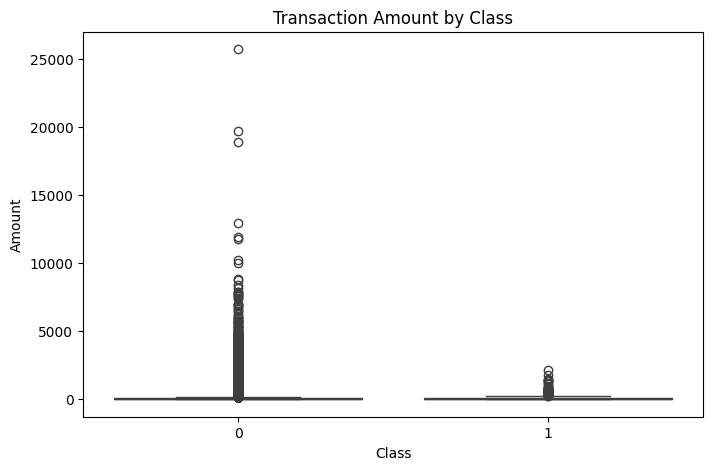

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")

plt.show()

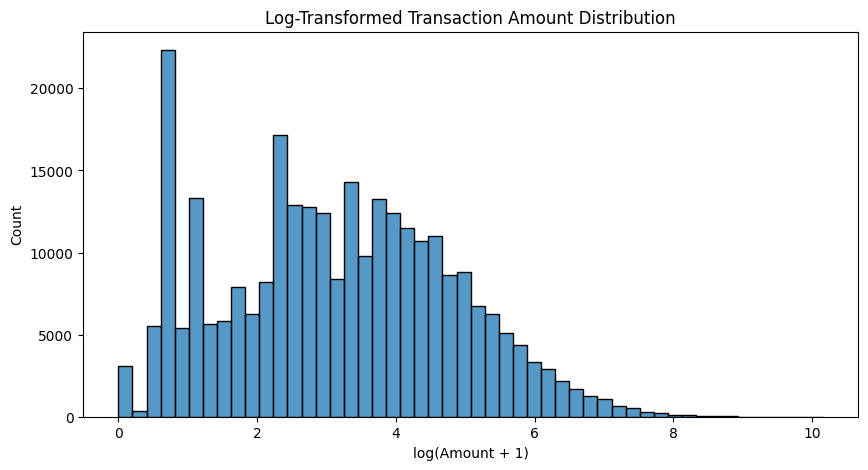

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df["Amount"]), bins=50)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(Amount + 1)")

plt.show()

In [ ]:
import pandera as pa

print(pa.__version__)

0.32.1


**# Data Validation**

In [ ]:
import pandera.pandas as pa
from pandera import Check

schema = pa.DataFrameSchema(
    {
        "Time": pa.Column(float, Check.ge(0)),
        "Amount": pa.Column(float, Check.ge(0)),
        "Class": pa.Column(int, Check.isin([0, 1])),
    },
    coerce=True
)

validated_df = schema.validate(df[["Time", "Amount", "Class"]])

print("✅ Data validation passed successfully!")
validated_df.head()

✅ Data validation passed successfully!


,Time,Amount,Class
0,0.0,149.62,0
1,0.0,2.69,0
2,1.0,378.66,0
3,1.0,123.50,0
4,2.0,69.99,0


In [ ]:
validated_df = schema.validate(df)

print("✅ Data validation passed successfully!")

✅ Data validation passed successfully!


In [ ]:
print("========== Data Validation Summary ==========")
print(f"Rows: {validated_df.shape[0]}")
print(f"Columns: {validated_df.shape[1]}")
print(f"Missing Values: {validated_df.isnull().sum().sum()}")
print(f"Duplicate Rows: {validated_df.duplicated().sum()}")
print("=============================================")

========== Data Validation Summary ==========
Rows: 284807
Columns: 31
Missing Values: 0
Duplicate Rows: 1081


**# Data Preprocessing**

In [ ]:
# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [ ]:
# Sort by Time
df = df.sort_values("Time").reset_index(drop=True)

# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# 80% for training, 20% for testing
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (227845, 30)
Testing Set : (56962, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

print("Amount feature scaled successfully!")

Amount feature scaled successfully!


In [ ]:
print(X_train["Amount"].describe())

count    2.278450e+05
mean    -7.578041e-17
std      1.000002e+00
min     -3.625699e-01
25%     -3.386181e-01
50%     -2.691579e-01
75%     -4.325262e-02
max      7.810560e+01
Name: Amount, dtype: float64


In [ ]:
print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [ ]:
print(X_train["Amount"].describe())

count    2.278450e+05
mean    -7.578041e-17
std      1.000002e+00
min     -3.625699e-01
25%     -3.386181e-01
50%     -2.691579e-01
75%     -4.325262e-02
max      7.810560e+01
Name: Amount, dtype: float64


**# Model Training - Logistic Regression (Baseline)**

In [ ]:
# Model Training - Logistic Regression (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


In [ ]:
# Predict class labels
y_pred = logistic_model.predict(X_test)

# Predict probabilities
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("========== Logistic Regression ==========")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.4f}")

========== Logistic Regression ==========
Accuracy : 0.9993
Precision: 0.9737
Recall   : 0.4933
F1 Score : 0.6549
ROC-AUC  : 0.9668
PR-AUC   : 0.7304


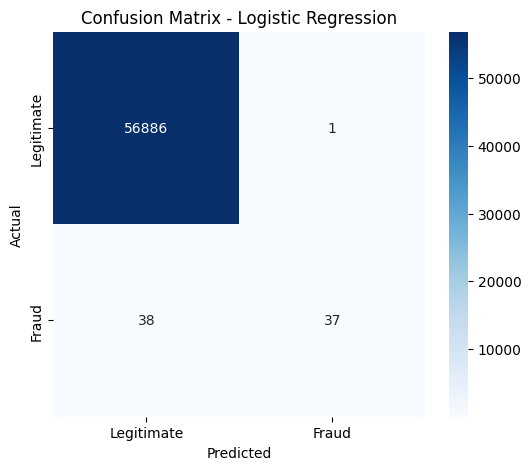

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost model trained successfully!")

✅ XGBoost model trained successfully!


In [ ]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
print("========== XGBoost ==========")

print(f"Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall   : {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, xgb_prob):.4f}")

========== XGBoost ==========
Accuracy : 0.9992
Precision: 0.7424
Recall   : 0.6533
F1 Score : 0.6950
ROC-AUC  : 0.8964
PR-AUC   : 0.5418


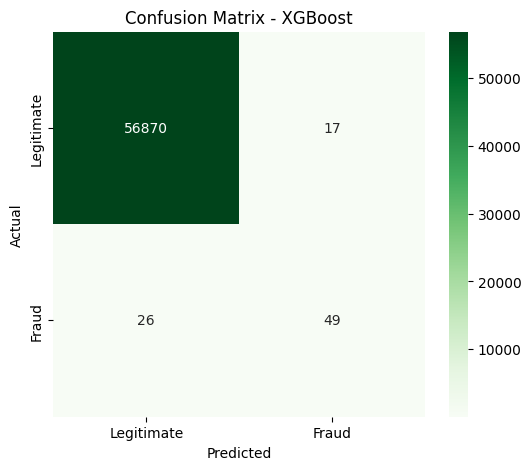

In [ ]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [ ]:
print("========== XGBoost ==========")

print(f"Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall   : {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, xgb_prob):.4f}")

========== XGBoost ==========
Accuracy : 0.9992
Precision: 0.7424
Recall   : 0.6533
F1 Score : 0.6950
ROC-AUC  : 0.8964
PR-AUC   : 0.5418


In [ ]:
XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=580
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

** Tune it better **

In [ ]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", negative)
print("Positive samples:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Negative samples: 227428
Positive samples: 417
Scale Pos Weight: 545.3908872901678


In [ ]:
from xgboost import XGBClassifier

xgb_tuned = XGBClassifier(
    random_state=42,
    eval_metric="logloss",

    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight
)

xgb_tuned.fit(X_train, y_train)

print("✅ Tuned XGBoost trained successfully!")

✅ Tuned XGBoost trained successfully!


In [ ]:
tuned_pred = xgb_tuned.predict(X_test)

tuned_prob = xgb_tuned.predict_proba(X_test)[:,1]

In [ ]:
print("========== Tuned XGBoost ==========")

print(f"Accuracy : {accuracy_score(y_test, tuned_pred):.4f}")
print(f"Precision: {precision_score(y_test, tuned_pred):.4f}")
print(f"Recall   : {recall_score(y_test, tuned_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, tuned_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, tuned_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, tuned_prob):.4f}")

========== Tuned XGBoost ==========
Accuracy : 0.9995
Precision: 0.8636
Recall   : 0.7600
F1 Score : 0.8085
ROC-AUC  : 0.9849
PR-AUC   : 0.8021


In [ ]:
XGBClassifier()

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

ex2

In [ ]:
xgb_exp2 = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1
)

xgb_exp2.fit(X_train, y_train)

pred2 = xgb_exp2.predict(X_test)
prob2 = xgb_exp2.predict_proba(X_test)[:,1]

print("========== Experiment 2 ==========")
print(f"Accuracy : {accuracy_score(y_test, pred2):.4f}")
print(f"Precision: {precision_score(y_test, pred2):.4f}")
print(f"Recall   : {recall_score(y_test, pred2):.4f}")
print(f"F1 Score : {f1_score(y_test, pred2):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, prob2):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, prob2):.4f}")

========== Experiment 2 ==========
Accuracy : 0.9994
Precision: 0.8889
Recall   : 0.6400
F1 Score : 0.7442
ROC-AUC  : 0.9801
PR-AUC   : 0.6460


ex3

In [ ]:
xgb_exp3 = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight
)

xgb_exp3.fit(X_train, y_train)

pred3 = xgb_exp3.predict(X_test)
prob3 = xgb_exp3.predict_proba(X_test)[:,1]

print("========== Experiment 3 ==========")
print(f"Accuracy : {accuracy_score(y_test, pred3):.4f}")
print(f"Precision: {precision_score(y_test, pred3):.4f}")
print(f"Recall   : {recall_score(y_test, pred3):.4f}")
print(f"F1 Score : {f1_score(y_test, pred3):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, prob3):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, prob3):.4f}")

========== Experiment 3 ==========
Accuracy : 0.9995
Precision: 0.8636
Recall   : 0.7600
F1 Score : 0.8085
ROC-AUC  : 0.9849
PR-AUC   : 0.8021


**Threshold Analysis**

In [ ]:
y_prob = logistic_model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

thresholds = [0.3, 0.5, 0.7]

results = []

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.3,0.928571,0.520000,0.666667
1,0.5,0.973684,0.493333,0.654867
2,0.7,0.972222,0.466667,0.630631


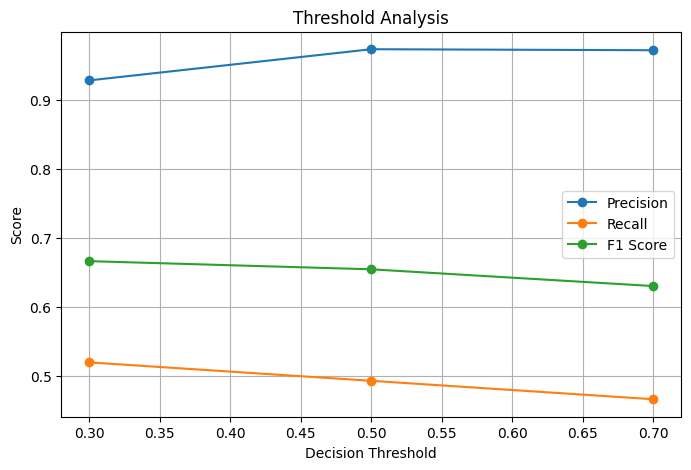

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title("Threshold Analysis")

plt.legend()

plt.grid(True)

plt.show()

evaluating 21 thresholds to identify the threshold with the highest F1-score.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import pandas as pd
import numpy as np

thresholds = np.arange(0.00, 1.01, 0.05)

results = []

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    cm = confusion_matrix(y_test, predictions)

    tn, fp, fn, tp = cm.ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.00,0.001317,1.000000,0.002630,56887,0
1,0.05,0.706667,0.706667,0.706667,22,22
2,0.10,0.758065,0.626667,0.686131,15,28
3,0.15,0.840000,0.560000,0.672000,8,33
4,0.20,0.891304,0.546667,0.677686,5,34
5,0.25,0.928571,0.520000,0.666667,3,36
6,0.30,0.928571,0.520000,0.666667,3,36
7,0.35,0.973684,0.493333,0.654867,1,38
8,0.40,0.973684,0.493333,0.654867,1,38
9,0.45,0.973684,0.493333,0.654867,1,38


automatucally finding the best one

In [ ]:
best = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print(best)

Threshold           0.050000
Precision           0.706667
Recall              0.706667
F1 Score            0.706667
False Positives    22.000000
False Negatives    22.000000
Name: 1, dtype: float64


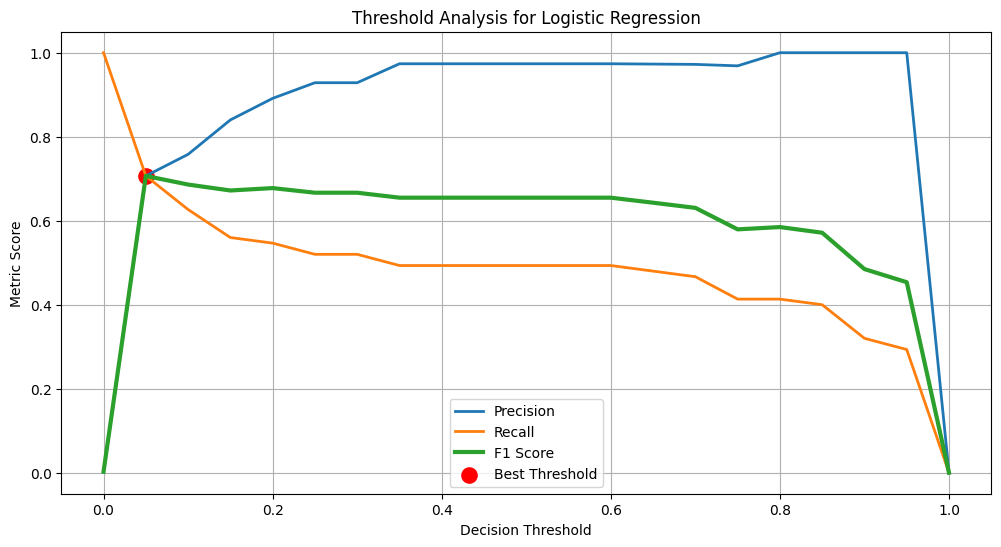

In [ ]:
#plot everything
plt.figure(figsize=(12,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1 Score",
    linewidth=3
)

plt.scatter(
    best["Threshold"],
    best["F1 Score"],
    color="red",
    s=120,
    label="Best Threshold"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Score")

plt.title("Threshold Analysis for Logistic Regression")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
print("="*50)

print("Best Threshold")

print("="*50)

print(f"Threshold         : {best['Threshold']:.2f}")
print(f"Precision         : {best['Precision']:.4f}")
print(f"Recall            : {best['Recall']:.4f}")
print(f"F1 Score          : {best['F1 Score']:.4f}")
print(f"False Positives   : {int(best['False Positives'])}")
print(f"False Negatives   : {int(best['False Negatives'])}")

Best Threshold
Threshold         : 0.05
Precision         : 0.7067
Recall            : 0.7067
F1 Score          : 0.7067
False Positives   : 22
False Negatives   : 22


In [ ]:
import joblib

joblib.dump(logistic_model, "logistic_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!
